In [1]:
!pip install -U pip wheel setuptools
!pip install torch torchvision timm einops python-chess pillow tqdm numpy matplotlib pandas
!pip install pickleshare   # optional, silences IPython warning

  Attempting uninstall: wheel
    Found existing installation: wheel 0.46.3
    Uninstalling wheel-0.46.3:
      Successfully uninstalled wheel-0.46.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 54.7 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 76.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 43.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 103.1 MB/s  0:00:00
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147879 sha256=2795ce69a71cfa697ebe13a426707cf8447eb707ea212c44fac19b4656f4b4ac
  Stored in directory: /teamspace/studios/this_studio/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [timm]8/9 [timm]ngface_hub]


In [2]:
!python train.py --mode train \
  --pgn /teamspace/studios/this_studio/Gukesh.pgn \
  --max-games 10000 \
  --epochs 10 \
  --batch-size 256 \
  --num-workers 8 \
  --prefetch-factor 4 \
  --beta-jac 1e-3

parse pgn: 10000it [00:48, 205.73it/s]
parsed 10000 games, 942240 positions -> outputs/chess_cache.pt
Using cached parsed PGN: outputs/chess_cache.pt
render boards: 100%|█████████████████| 942240/942240 [03:41<00:00, 4260.41it/s]
cached (942240, 128, 128, 3) uint8 -> outputs/chess_boards.npy (46.3 GB; page cache will hold it in 240GB RAM)
train: 703,529 windows from 9,000 games
val: 78,711 windows from 1,000 games
Device: cuda; epochs=10; steps/epoch=2748; batch=256; amp=bf16
E001 | train loss 1.9096 pred 0.0479 pol_acc 0.016 nr 0.98 | val loss 3.6797 pred 0.0529 pol_acc 0.023 nr 0.97
saved best: outputs/lewm_chess_best.pt (val pred_loss=0.052920)
E002 | train loss 1.5120 pred 0.0518 pol_acc 0.039 nr 0.97 | val loss 3.5501 pred 0.0468 pol_acc 0.053 nr 0.98
saved best: outputs/lewm_chess_best.pt (val pred_loss=0.046756)
E003 | train loss 1.3124 pred 0.0432 pol_acc 0.085 nr 0.98 | val loss 3.2259 pred 0.0396 pol_acc 0.094 nr 0.98
saved best: outputs/lewm_chess_best.pt (val pred_loss=0.03

In [4]:
!sudo apt update && sudo apt install -y stockfish

Ign:1 https://dfw1.ec2.archive.ubuntu.com/ubuntu noble InRelease
Ign:2 https://dfw1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease       
Ign:3 https://dfw1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease     
Ign:4 https://dfw1.ec2.archive.ubuntu.com/ubuntu noble-security InRelease      
Get:5 https://cli.github.com/packages stable InRelease [3917 B]                
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease [1581 B]
Get:7 https://download.docker.com/linux/ubuntu noble InRelease [48.5 kB]       
Hit:8 https://nvidia.github.io/libnvidia-container/stable/deb/amd64  InRelease 
Hit:9 https://mirrors.edge.kernel.org/ubuntu noble InRelease                   
Hit:10 https://mirrors.edge.kernel.org/ubuntu noble-updates InRelease          
Hit:11 https://mirrors.edge.kernel.org/ubuntu noble-backports InRelease        
Hit:12 https://mirrors.edge.kernel.org/ubuntu noble-security InRelease         
Get:13 https://cli.github.com/pack

In [12]:
import random
import numpy as np
import torch
import chess
import chess.engine
import train

# Load checkpoint
ckpt_path = "outputs/lewm_chess_latest.pt"  # or best
ckpt = torch.load(ckpt_path, map_location=train.DEVICE, weights_only=False)

# Create a fresh config with the correct stockfish path
cfg = train.Config()
cfg.pgn_path = "/teamspace/studios/this_studio/Gukesh.pgn"
cfg.stockfish_path = "/usr/games/stockfish"

# Override any config values from the checkpoint that are relevant (except stockfish path)
for k, v in ckpt["cfg"].items():
    if k in train.asdict(cfg) and k != "stockfish_path":
        setattr(cfg, k, v)

# Load model
model = train.ChessLeWM(cfg).to(train.DEVICE).eval()
model.load_state_dict(ckpt["model"])

# Define evaluation function
def eval_with_config(cfg, model, sample_fens):
    eng = chess.engine.SimpleEngine.popen_uci(cfg.stockfish_path)
    legal_ok, top1, top5, deltas = [], [], [], []
    for fen in sample_fens:
        b = chess.Board(fen)
        if b.is_game_over():
            continue
        cand = train.masked_policy_topk(model, b, k=5)
        legal_ok.append(all(m in b.legal_moves for m in cand))
        info = eng.analyse(b, chess.engine.Limit(depth=cfg.stockfish_depth),
                           multipv=min(5, b.legal_moves.count()))
        infos = info if isinstance(info, list) else [info]
        sf_moves = [e["pv"][0] for e in infos if "pv" in e and e["pv"]]
        if not sf_moves:
            continue
        top1.append(cand[0] == sf_moves[0])
        top5.append(sf_moves[0] in cand)
        b2 = b.copy(); b2.push(cand[0])
        sc_best = infos[0]["score"].pov(b.turn).score(mate_score=10000)
        sc_mine = eng.analyse(b2, chess.engine.Limit(depth=cfg.stockfish_depth)
                              )["score"].pov(b.turn).score(mate_score=10000)
        if sc_best is not None and sc_mine is not None:
            deltas.append(max(0.0, float(sc_best - sc_mine)))
    eng.quit()
    print(f"legal_move_rate      {np.mean(legal_ok):.2f}")
    print(f"stockfish_top1_match {np.mean(top1):.2f}")
    print(f"stockfish_top5_match {np.mean(top5):.2f}")
    print(f"mean_delta_cp        {np.mean(deltas):.2f}")
    print(f"median_delta_cp      {np.median(deltas):.0f}")

# Get validation positions (same as stockfish_eval does)
d = torch.load(cfg.cache_path, weights_only=False)
bounds = d["boundaries"].tolist() + [len(d["fens"])]
n = d["n_games"]
nval = max(1, int(n * cfg.val_split))
val_fens = []
for g in range(n - nval, n):
    for i in range(bounds[g], bounds[g + 1]):
        val_fens.append(d["fens"][i])

random.seed(cfg.seed)
sample = random.sample(val_fens, min(cfg.stockfish_positions, len(val_fens)))

# Run evaluation
eval_with_config(cfg, model, sample)

legal_move_rate      1.00
stockfish_top1_match 0.38
stockfish_top5_match 0.67
mean_delta_cp        148.95
median_delta_cp      12


In [15]:
import torch
import numpy as np
import train
from tqdm import tqdm

def export_arrays_fixed(cfg, ckpt_path, out="exports/chess_seed0.npz"):
    """Fixed version of export_arrays that normalises frames correctly and detaches tensors."""
    ck = torch.load(ckpt_path, map_location=train.DEVICE, weights_only=False)
    model = train.ChessLeWM(cfg).to(train.DEVICE).eval()
    model.load_state_dict(ck["model"])
    
    vl = torch.utils.data.DataLoader(
        train.CachedChessDS(cfg, "val"),
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    errs_true, errs_zero, errs_shuf = [], [], []
    for frames, moves, result, progress in tqdm(vl, desc="export"):
        frames = train.frames_to_gpu(frames)
        moves = moves.to(train.DEVICE)
        progress = progress.to(train.DEVICE)
        
        emb = model.encode(frames)
        H = cfg.history_size
        tgt = emb[:, H]
        
        a_true = model.action_enc(moves, progress)[:, :H]
        a_zero = torch.zeros_like(a_true)
        perm = torch.randperm(emb.shape[0], device=emb.device)
        a_shuf = model.action_enc(moves[perm], progress[perm])[:, :H]
        
        for a, dst in ((a_true, errs_true), (a_zero, errs_zero), (a_shuf, errs_shuf)):
            p = model.predict(emb[:, :H], a)[:, -1]
            # FIX: detach() before .numpy()
            dst.append(((p - tgt) ** 2).mean(-1).detach().cpu().numpy())
    
    import os
    os.makedirs(os.path.dirname(out) if os.path.dirname(out) else '.', exist_ok=True)
    np.savez(out,
             err_true=np.concatenate(errs_true),
             err_zero=np.concatenate(errs_zero),
             err_shuffled=np.concatenate(errs_shuf))
    print(f"Exported to {out}")

# Run the fixed export
cfg = train.Config()
cfg.pgn_path = "/teamspace/studios/this_studio/Gukesh.pgn"
cfg.batch_size = 64
export_arrays_fixed(cfg, "outputs/lewm_chess_latest.pt")

val: 78,711 windows from 1,000 games


export: 100%|██████████| 1230/1230 [00:38<00:00, 31.58it/s]

Exported to exports/chess_seed0.npz


In [16]:
import torch
import train
from tqdm import tqdm

ckpt_path = "outputs/lewm_chess_best.pt"
ckpt = torch.load(ckpt_path, map_location=train.DEVICE, weights_only=False)

cfg = train.Config()
cfg.pgn_path = "/teamspace/studios/this_studio/Gukesh.pgn"
for k, v in ckpt["cfg"].items():
    if k in train.asdict(cfg):
        setattr(cfg, k, v)

model = train.ChessLeWM(cfg).to(train.DEVICE).eval()
model.load_state_dict(ckpt["model"])

val_ds = train.CachedChessDS(cfg, "val")
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)

top1 = 0
top5 = 0
total = 0

for frames, moves, result, progress in tqdm(val_loader, desc="Policy accuracy"):
    H = cfg.history_size
    true_move_idx = moves[0, H].item()
    with torch.no_grad():
        frames = frames.to(train.DEVICE)
        frames = train.frames_to_gpu(frames)
        emb = model.encode(frames)                     # (1,T,D)
        z = emb[:, :H]
        logits = model.policy_head(z).squeeze(0)       # (H, vocab)
        pred_logits = logits[-1]                       # (vocab,)
        pred_top1 = pred_logits.argmax().item()
        if pred_top1 == true_move_idx:
            top1 += 1
        top5_idxs = pred_logits.argsort(descending=True)[:5]
        if true_move_idx in top5_idxs:
            top5 += 1
        total += 1

print(f"Validation policy top-1 accuracy: {top1/total:.3f}")
print(f"Validation policy top-5 accuracy: {top5/total:.3f}")

val: 78,711 windows from 1,000 games


Policy accuracy: 100%|██████████| 78711/78711 [04:55<00:00, 266.30it/s]

Validation policy top-1 accuracy: 0.029
Validation policy top-5 accuracy: 0.102


In [17]:
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=4)

mse = 0
total = 0
for frames, moves, result, progress in val_loader:
    frames = frames.to(train.DEVICE)
    frames = train.frames_to_gpu(frames)
    with torch.no_grad():
        emb = model.encode(frames)
        vpred = torch.tanh(model.value_head(emb.mean(1))).squeeze(-1)
    wdl = torch.where(result == 0, 1.0, torch.where(result == 1, -1.0, 0.0)).float().to(train.DEVICE)
    mse += torch.mean((vpred - wdl) ** 2).item() * frames.size(0)
    total += frames.size(0)

print(f"Value head MSE (WDL): {mse/total:.4f}")

Value head MSE (WDL): 0.5858


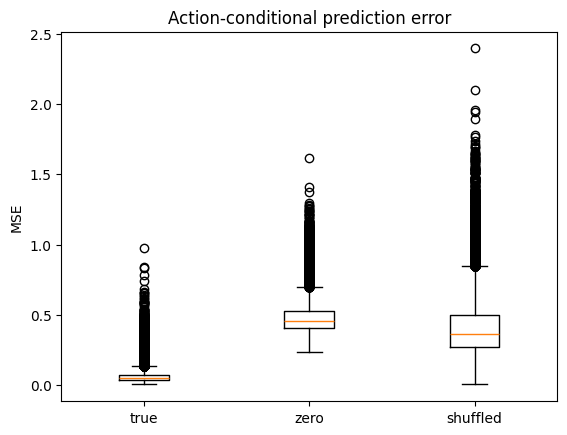

In [19]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("exports/chess_seed0.npz")
err_true = data["err_true"]
err_zero = data["err_zero"]
err_shuffled = data["err_shuffled"]

plt.boxplot([err_true, err_zero, err_shuffled], labels=["true", "zero", "shuffled"])
plt.ylabel("MSE")
plt.title("Action‑conditional prediction error")
plt.show()

In [1]:
import random
import numpy as np
import torch
import chess
import chess.engine
import train

ckpt_path = "outputs/lewm_chess_latest.pt"   # or best
ckpt = torch.load(ckpt_path, map_location=train.DEVICE, weights_only=False)

cfg = train.Config()
cfg.pgn_path = "/teamspace/studios/this_studio/Gukesh.pgn"
cfg.stockfish_path = "/usr/games/stockfish"
for k, v in ckpt["cfg"].items():
    if k in train.asdict(cfg) and k != "stockfish_path":
        setattr(cfg, k, v)

model = train.ChessLeWM(cfg).to(train.DEVICE).eval()
model.load_state_dict(ckpt["model"])

def eval_with_config(cfg, model):
    eng = chess.engine.SimpleEngine.popen_uci(cfg.stockfish_path)
    d = torch.load(cfg.cache_path, weights_only=False)
    bounds = d["boundaries"].tolist() + [len(d["fens"])]
    n = d["n_games"]; nval = max(1, int(n * cfg.val_split))
    val_fens = [d["fens"][i] for g in range(n - nval, n) for i in range(bounds[g], bounds[g+1])]
    random.seed(cfg.seed)
    sample = random.sample(val_fens, min(cfg.stockfish_positions, len(val_fens)))
    legal_ok, top1, top5, deltas = [], [], [], []
    for fen in sample:
        b = chess.Board(fen)
        if b.is_game_over():
            continue
        cand = train.masked_policy_topk(model, b, k=5)
        legal_ok.append(all(m in b.legal_moves for m in cand))
        info = eng.analyse(b, chess.engine.Limit(depth=cfg.stockfish_depth),
                           multipv=min(5, b.legal_moves.count()))
        infos = info if isinstance(info, list) else [info]
        sf_moves = [e["pv"][0] for e in infos if "pv" in e and e["pv"]]
        if not sf_moves:
            continue
        top1.append(cand[0] == sf_moves[0])
        top5.append(sf_moves[0] in cand)
        b2 = b.copy(); b2.push(cand[0])
        sc_best = infos[0]["score"].pov(b.turn).score(mate_score=10000)
        sc_mine = eng.analyse(b2, chess.engine.Limit(depth=cfg.stockfish_depth)
                              )["score"].pov(b.turn).score(mate_score=10000)
        if sc_best is not None and sc_mine is not None:
            deltas.append(max(0.0, float(sc_best - sc_mine)))
    eng.quit()
    print(f"legal_move_rate      {np.mean(legal_ok):.2f}")
    print(f"stockfish_top1_match {np.mean(top1):.2f}")
    print(f"stockfish_top5_match {np.mean(top5):.2f}")
    print(f"mean_delta_cp        {np.mean(deltas):.2f}")
    print(f"median_delta_cp      {np.median(deltas):.0f}")

eval_with_config(cfg, model)

legal_move_rate      1.00
stockfish_top1_match 0.38
stockfish_top5_match 0.67
mean_delta_cp        148.95
median_delta_cp      12


In [ ]:
import os
os._exit(00)

In [21]:
import torch
import numpy as np
import train
from tqdm import tqdm

def export_full_arrays(cfg, ckpt_path, out="exports/chess_full.npz"):
    ck = torch.load(ckpt_path, map_location=train.DEVICE, weights_only=False)
    model = train.ChessLeWM(cfg).to(train.DEVICE).eval()
    model.load_state_dict(ck["model"])
    
    vl = torch.utils.data.DataLoader(
        train.CachedChessDS(cfg, "val"),
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    z_list, act_list = [], []
    pred_true_list, pred_zero_list, pred_shuffle_list, pred_random_list = [], [], [], []
    
    for frames, moves, result, progress in tqdm(vl, desc="export full"):
        frames = train.frames_to_gpu(frames)
        moves = moves.to(train.DEVICE)
        progress = progress.to(train.DEVICE)
        
        emb = model.encode(frames)                    # (B, T, D)
        act = model.action_enc(moves, progress)       # (B, T, D)
        
        # Use all but last action as input, predict next latent
        z = emb                                     # (B, T, D)
        a = act[:, :-1]                              # (B, T-1, D)  (action embeddings)
        target = z[:, 1:]                            # (B, T-1, D)
        
        # Corruptions
        zero = torch.zeros_like(a)
        perm = torch.randperm(a.shape[0], device=a.device)
        shuffle = a[perm]
        # Random Gaussian with same per‑dim mean/std as a
        mu = a.float().mean(dim=(0,1), keepdim=True)
        sd = a.float().std(dim=(0,1), keepdim=True).clamp_min(1e-6)
        rand = (mu + sd * torch.randn_like(a.float())).to(a.dtype)
        
        pred_true = model.predict(z[:, :-1], a)      # (B, T-1, D)
        pred_zero = model.predict(z[:, :-1], zero)
        pred_shuffle = model.predict(z[:, :-1], shuffle)
        pred_random = model.predict(z[:, :-1], rand)
        
        z_list.append(train.to_numpy(z).astype(np.float32))
        act_list.append(train.to_numpy(a).astype(np.float32))
        pred_true_list.append(train.to_numpy(pred_true).astype(np.float32))
        pred_zero_list.append(train.to_numpy(pred_zero).astype(np.float32))
        pred_shuffle_list.append(train.to_numpy(pred_shuffle).astype(np.float32))
        pred_random_list.append(train.to_numpy(pred_random).astype(np.float32))
    
    np.savez_compressed(out,
        z=np.concatenate(z_list, axis=0),
        actions=np.concatenate(act_list, axis=0),
        pred_true=np.concatenate(pred_true_list, axis=0),
        pred_zero=np.concatenate(pred_zero_list, axis=0),
        pred_shuffle=np.concatenate(pred_shuffle_list, axis=0),
        pred_random=np.concatenate(pred_random_list, axis=0)
    )
    print(f"Saved full arrays to {out}")

# Run it
cfg = train.Config()
cfg.pgn_path = "/teamspace/studios/this_studio/Gukesh.pgn"
cfg.batch_size = 32   # reduce if OOM
export_full_arrays(cfg, "outputs/lewm_chess_latest.pt", "exports/chess_full.npz")

AcceleratorError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


true MSE mean: 0.0628
zero MSE mean: 0.4793
shuffled MSE mean: 0.4067
ratio zero/true: 7.63
ratio shuffled/true: 6.48


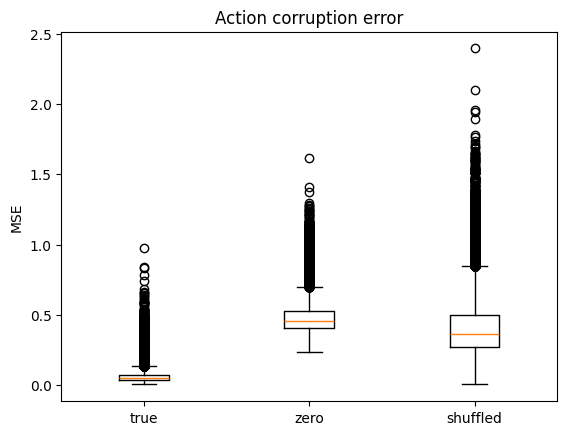

In [23]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("exports/chess_seed0.npz")
err_true = data["err_true"]
err_zero = data["err_zero"]
err_shuffled = data["err_shuffled"]

print(f"true MSE mean: {err_true.mean():.4f}")
print(f"zero MSE mean: {err_zero.mean():.4f}")
print(f"shuffled MSE mean: {err_shuffled.mean():.4f}")
print(f"ratio zero/true: {err_zero.mean() / err_true.mean():.2f}")
print(f"ratio shuffled/true: {err_shuffled.mean() / err_true.mean():.2f}")

plt.boxplot([err_true, err_zero, err_shuffled], labels=["true", "zero", "shuffled"])
plt.ylabel("MSE")
plt.title("Action corruption error")
plt.show()

In [1]:
import sys
import os
import importlib.util
import chess
import chess.engine
import chess.pgn
import torch
from datetime import datetime

# ------------------------------------------------------------
# 1. Dynamically import your script
# ------------------------------------------------------------
script_name = "train.py"
if not os.path.exists(script_name):
    raise FileNotFoundError(f"Could not find '{script_name}'")

spec = importlib.util.spec_from_file_location("train_script", script_name)
train_script = importlib.util.module_from_spec(spec)
sys.modules["train_script"] = train_script
spec.loader.exec_module(train_script)

Config = train_script.Config
ChessLeWM = train_script.ChessLeWM
masked_policy_topk = train_script.masked_policy_topk
DEVICE = train_script.DEVICE

# ------------------------------------------------------------
# 2. Load latest checkpoint (CPU first to avoid GPU asserts)
# ------------------------------------------------------------
cfg = Config()
latest_ckpt_path = os.path.join(cfg.out_dir, "lewm_chess_latest.pt")
if not os.path.exists(latest_ckpt_path):
    raise FileNotFoundError(f"No checkpoint at {latest_ckpt_path}")

print(f"Loading checkpoint from: {latest_ckpt_path}")
checkpoint = torch.load(latest_ckpt_path, map_location="cpu", weights_only=False)

for k, v in checkpoint["cfg"].items():
    if hasattr(cfg, k) and k != "stockfish_path":
        setattr(cfg, k, v)

cfg.stockfish_path = "/usr/games/stockfish"

model = ChessLeWM(cfg).to(DEVICE).eval()
model.load_state_dict(checkpoint["model"])
print(f"✅ Model loaded on {DEVICE} from epoch {checkpoint['epoch']}")

# ------------------------------------------------------------
# 3. Game settings
# ------------------------------------------------------------
white_player = "lewm"      # "lewm" or "stockfish"
black_player = "stockfish"
pgn_output = "lewm_vs_stockfish.pgn"

# ------------------------------------------------------------
# 4. Stockfish engine (if used)
# ------------------------------------------------------------
engine = None
if white_player == "stockfish" or black_player == "stockfish":
    try:
        engine = chess.engine.SimpleEngine.popen_uci(cfg.stockfish_path)
        print(f"Stockfish loaded from {cfg.stockfish_path}")
    except Exception as e:
        print(f"Stockfish error: {e}")
        engine = None

# ------------------------------------------------------------
# 5. Play game (only move output, no board prints)
# ------------------------------------------------------------
board = chess.Board()
game = chess.pgn.Game()
game.headers["Event"] = "LeWM vs Stockfish"
game.headers["Site"] = "Lightning.ai H100"
game.headers["Date"] = datetime.now().strftime("%Y.%m.%d")
game.headers["Round"] = "1"
game.headers["White"] = white_player.capitalize()
game.headers["Black"] = black_player.capitalize()
game.headers["Result"] = "*"

node = game
move_count = 0
max_moves = 200

print(f"\nGame: White = {white_player}, Black = {black_player}\n")

while not board.is_game_over() and move_count < max_moves:
    if board.turn == chess.WHITE:
        player = white_player
    else:
        player = black_player

    if player == "lewm":
        candidates = masked_policy_topk(model, board, k=1)
        if not candidates:
            move = list(board.legal_moves)[0]
            print("⚠️ LeWM fallback random")
        else:
            move = candidates[0]
        print(f"LeWM ({'White' if board.turn else 'Black'}): {board.san(move)}")
    elif player == "stockfish":
        if engine is None:
            move = list(board.legal_moves)[0]
        else:
            result = engine.play(board, chess.engine.Limit(depth=cfg.stockfish_depth))
            move = result.move
        print(f"Stockfish ({'White' if board.turn else 'Black'}): {board.san(move)}")
    else:
        raise ValueError(f"Unknown player: {player}")

    node = node.add_variation(move)
    board.push(move)
    move_count += 1

# ------------------------------------------------------------
# 6. Result and PGN
# ------------------------------------------------------------
if board.is_checkmate():
    winner = "White" if board.turn == chess.BLACK else "Black"
    result = "1-0" if winner == "White" else "0-1"
    print(f"\nCheckmate! {winner} wins.")
elif board.is_stalemate() or board.is_insufficient_material():
    result = "1/2-1/2"
    print("\nDraw.")
else:
    result = "*"
    print(f"\nGame stopped after {move_count} moves.")

game.headers["Result"] = result

with open(pgn_output, "w") as f:
    f.write(str(game))

print(f"PGN saved to {pgn_output}")

if engine:
    engine.quit()

Loading checkpoint from: outputs/lewm_chess_latest.pt
✅ Model loaded on cuda from epoch 10
Stockfish loaded from /usr/games/stockfish

Game: White = lewm, Black = stockfish

LeWM (White): e4
Stockfish (Black): c5
LeWM (White): Nf3
Stockfish (Black): d6
LeWM (White): d4
Stockfish (Black): cxd4
LeWM (White): Nxd4
Stockfish (Black): Nf6
LeWM (White): Nc3
Stockfish (Black): a6
LeWM (White): Be3
Stockfish (Black): e5
LeWM (White): Nb3
Stockfish (Black): Ng4
LeWM (White): Bc1
Stockfish (Black): Nf6
LeWM (White): Bg5
Stockfish (Black): Be7
LeWM (White): Bxf6
Stockfish (Black): Bxf6
LeWM (White): Qd3
Stockfish (Black): Bg5
LeWM (White): Nd5
Stockfish (Black): O-O
LeWM (White): h4
Stockfish (Black): Bh6
LeWM (White): g3
Stockfish (Black): Nc6
LeWM (White): c3
Stockfish (Black): f5
LeWM (White): exf5
Stockfish (Black): e4
LeWM (White): Qd2
Stockfish (Black): Bxd2+
LeWM (White): Kxd2
Stockfish (Black): Kh8
LeWM (White): Bg2
Stockfish (Black): Bxf5
LeWM (White): Nd4
Stockfish (Black): Nxd4
LeWM (W

In [ ]:
import os
os._exit(00)

In [10]:
import sys
import os
import importlib.util
import chess
import chess.engine
import chess.pgn
import torch
import random
from datetime import datetime

# ============================================================
# USER CONFIGURATION – EDIT THESE VALUES
# ============================================================
LEWM_COLOR = "white"          # "white" or "black" – which side LeWM plays
STOCKFISH_DEPTH = 18          # Stockfish search depth
LEWM_TOP_K = 1                # 1 = best move; >1 = random choice among top‑k moves
MAX_MOVES = 200               # safety limit
PGN_OUTPUT = "lewm_vs_stockfish.pgn"
# ============================================================

# Derive player roles from LEWM_COLOR
if LEWM_COLOR == "white":
    white_player = "lewm"
    black_player = "stockfish"
elif LEWM_COLOR == "black":
    white_player = "stockfish"
    black_player = "lewm"
else:
    raise ValueError("LEWM_COLOR must be 'white' or 'black'")

# ------------------------------------------------------------
# 1. Dynamically import your script
# ------------------------------------------------------------
script_name = "train.py"
if not os.path.exists(script_name):
    raise FileNotFoundError(f"Could not find '{script_name}'")

spec = importlib.util.spec_from_file_location("train_script", script_name)
train_script = importlib.util.module_from_spec(spec)
sys.modules["train_script"] = train_script
spec.loader.exec_module(train_script)

Config = train_script.Config
ChessLeWM = train_script.ChessLeWM
masked_policy_topk = train_script.masked_policy_topk
DEVICE = train_script.DEVICE

# ------------------------------------------------------------
# 2. Load latest checkpoint (CPU first to avoid GPU asserts)
# ------------------------------------------------------------
cfg = Config()
latest_ckpt_path = os.path.join(cfg.out_dir, "lewm_chess_latest.pt")
if not os.path.exists(latest_ckpt_path):
    raise FileNotFoundError(f"No checkpoint at {latest_ckpt_path}")

print(f"Loading checkpoint from: {latest_ckpt_path}")
checkpoint = torch.load(latest_ckpt_path, map_location="cpu", weights_only=False)

for k, v in checkpoint["cfg"].items():
    if hasattr(cfg, k) and k != "stockfish_path":
        setattr(cfg, k, v)

cfg.stockfish_path = "/usr/games/stockfish"
cfg.stockfish_depth = STOCKFISH_DEPTH   # apply user depth

model = ChessLeWM(cfg).to(DEVICE).eval()
model.load_state_dict(checkpoint["model"])
print(f"✅ Model loaded on {DEVICE} from epoch {checkpoint['epoch']}")

# ------------------------------------------------------------
# 3. Function to get LeWM move (top‑k with optional randomness)
# ------------------------------------------------------------
def get_lewm_move(board):
    # masked_policy_topk returns legal moves sorted by score (highest first)
    candidates = masked_policy_topk(model, board, k=LEWM_TOP_K)
    if not candidates:
        # fallback to random legal move
        return random.choice(list(board.legal_moves))
    if LEWM_TOP_K == 1:
        return candidates[0]
    else:
        # randomly select among the top-k moves
        return random.choice(candidates)

# ------------------------------------------------------------
# 4. Stockfish engine
# ------------------------------------------------------------
engine = None
if white_player == "stockfish" or black_player == "stockfish":
    try:
        engine = chess.engine.SimpleEngine.popen_uci(cfg.stockfish_path)
        print(f"Stockfish loaded from {cfg.stockfish_path} (depth={STOCKFISH_DEPTH})")
    except Exception as e:
        print(f"Stockfish error: {e}")
        engine = None

# ------------------------------------------------------------
# 5. Play game (only move output, no board prints)
# ------------------------------------------------------------
board = chess.Board()
game = chess.pgn.Game()
game.headers["Event"] = f"LeWM vs Stockfish (LeWM top‑k={LEWM_TOP_K})"
game.headers["Site"] = "Lightning.ai H100"
game.headers["Date"] = datetime.now().strftime("%Y.%m.%d")
game.headers["Round"] = "1"
game.headers["White"] = white_player.capitalize()
game.headers["Black"] = black_player.capitalize()
game.headers["Result"] = "*"

node = game
move_count = 0

print(f"\nGame: White = {white_player}, Black = {black_player}")
print(f"LeWM top‑k = {LEWM_TOP_K} | Stockfish depth = {STOCKFISH_DEPTH}\n")

while not board.is_game_over() and move_count < MAX_MOVES:
    if board.turn == chess.WHITE:
        player = white_player
    else:
        player = black_player

    if player == "lewm":
        move = get_lewm_move(board)
        print(f"LeWM ({'White' if board.turn else 'Black'}): {board.san(move)}")
    elif player == "stockfish":
        if engine is None:
            move = random.choice(list(board.legal_moves))
        else:
            result = engine.play(board, chess.engine.Limit(depth=STOCKFISH_DEPTH))
            move = result.move
        print(f"Stockfish ({'White' if board.turn else 'Black'}): {board.san(move)}")
    else:
        raise ValueError(f"Unknown player: {player}")

    node = node.add_variation(move)
    board.push(move)
    move_count += 1

# ------------------------------------------------------------
# 6. Result and PGN
# ------------------------------------------------------------
if board.is_checkmate():
    winner = "White" if board.turn == chess.BLACK else "Black"
    result = "1-0" if winner == "White" else "0-1"
    print(f"\nCheckmate! {winner} wins.")
elif board.is_stalemate() or board.is_insufficient_material():
    result = "1/2-1/2"
    print("\nDraw.")
else:
    result = "*"
    print(f"\nGame stopped after {move_count} moves.")

game.headers["Result"] = result

with open(PGN_OUTPUT, "w") as f:
    f.write(str(game))

print(f"PGN saved to {PGN_OUTPUT}")

if engine:
    engine.quit()

Loading checkpoint from: outputs/lewm_chess_latest.pt
✅ Model loaded on cuda from epoch 10
Stockfish loaded from /usr/games/stockfish (depth=18)

Game: White = lewm, Black = stockfish
LeWM top‑k = 1 | Stockfish depth = 18

LeWM (White): e4
Stockfish (Black): c5
LeWM (White): Nf3
Stockfish (Black): Nc6
LeWM (White): Bb5
Stockfish (Black): g6
LeWM (White): O-O
Stockfish (Black): Bg7
LeWM (White): Re1
Stockfish (Black): e5
LeWM (White): Bxc6
Stockfish (Black): dxc6
LeWM (White): d3
Stockfish (Black): b6
LeWM (White): Nbd2
Stockfish (Black): Be6
LeWM (White): Nc4
Stockfish (Black): Qc7
LeWM (White): b3
Stockfish (Black): f6
LeWM (White): a4
Stockfish (Black): Nh6
LeWM (White): Bb2
Stockfish (Black): Nf7
LeWM (White): Qd2
Stockfish (Black): O-O
LeWM (White): h3
Stockfish (Black): Rad8
LeWM (White): Rad1
Stockfish (Black): Rd7
LeWM (White): b4
Stockfish (Black): Bxc4
LeWM (White): bxc5
Stockfish (Black): Be6
LeWM (White): d4
Stockfish (Black): bxc5
LeWM (White): dxe5
Stockfish (Black): Rxd2


In [1]:
import os
# This forces CUDA to report errors exactly where they happen
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ['TORCH_USE_CUDA_DSA'] = "1"

In [15]:
import os
import torch
import chess
import importlib.util

# ------------------------------------------------------------
# 1. Dynamically import your script (handles spaces)
# ------------------------------------------------------------
script_name = "train.py" # Change to "train.py" if you renamed it
if not os.path.exists(script_name):
    raise FileNotFoundError(f"Could not find '{script_name}'.")

spec = importlib.util.spec_from_file_location("train_script", script_name)
train = importlib.util.module_from_spec(spec)
import sys
sys.modules["train_script"] = train
spec.loader.exec_module(train)

# ------------------------------------------------------------
# 2. CPU-Bridge: Load Model Safely
# ------------------------------------------------------------
ckpt_path = "outputs/lewm_chess_latest.pt"
print("Loading model securely via CPU...")

# Load weights to system RAM first
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

# Sync config
cfg = train.Config()
for k, v in ckpt["cfg"].items():
    if hasattr(cfg, k):
        setattr(cfg, k, v)

# Build architecture and push to GPU
model = train.ChessLeWM(cfg).eval()
model.load_state_dict(ckpt["model"])
model = model.to(train.DEVICE)
print(f"✅ Model successfully loaded and pushed to [{train.DEVICE}]!")

# ------------------------------------------------------------
# 3. Predictor Function
# ------------------------------------------------------------
def analyze_fen(fen_string: str, k: int = 5):
    try:
        board = chess.Board(fen_string)
    except ValueError:
        print(f"\n❌ Invalid FEN string: {fen_string}")
        return

    print(f"\n🔍 Analyzing Position:")
    print(f"FEN: {fen_string}")
    print("-" * 25)
    print(board)
    print("-" * 25)

    if board.is_game_over():
        print("This game is already over!")
        return

    # Call your script's masked policy function
    top_moves = train.masked_policy_topk(model, board, k=k)
    
    turn_str = "White" if board.turn == chess.WHITE else "Black"
    print(f"🏆 LeWM Top {len(top_moves)} Moves for {turn_str}:")
    
    for i, move in enumerate(top_moves, 1):
        print(f"  {i}. {board.san(move):<6} (UCI: {move.uci()})")

# ------------------------------------------------------------
# 4. Test it Out
# ------------------------------------------------------------
# Change this string to whatever FEN you want to test!
my_fen = "rnbqk2r/p4ppp/2p1p3/8/Pp1P2Pb/1B6/NP3P1P/R1BQR1K1 w kq - 0 14" # Ruy Lopez / Spanish Game

analyze_fen(my_fen, k=5)

Loading model securely via CPU...
✅ Model successfully loaded and pushed to [cuda]!

🔍 Analyzing Position:
FEN: rnbqk2r/p4ppp/2p1p3/8/Pp1P2Pb/1B6/NP3P1P/R1BQR1K1 w kq - 0 14
-------------------------
r n b q k . . r
p . . . . p p p
. . p . p . . .
. . . . . . . .
P p . P . . P b
. B . . . . . .
N P . . . P . P
R . B Q R . K .
-------------------------
🏆 LeWM Top 5 Moves for White:
  1. Qd3    (UCI: d1d3)
  2. Bg5    (UCI: c1g5)
  3. Be3    (UCI: c1e3)
  4. Bd2    (UCI: c1d2)
  5. Bf4    (UCI: c1f4)


In [2]:
import sys
import os
import importlib.util
import chess
import chess.engine
import torch

# 1. Force everything to CPU for debugging
DEVICE = torch.device("cpu")

# 2. Import your script
script_name = "train.py" 
spec = importlib.util.spec_from_file_location("train_script", script_name)
train_script = importlib.util.module_from_spec(spec)
sys.modules["train_script"] = train_script
spec.loader.exec_module(train_script)

Config = train_script.Config
ChessLeWM = train_script.ChessLeWM
masked_policy_topk = train_script.masked_policy_topk

# 3. Load Checkpoint directly to CPU
cfg = Config()
latest_ckpt_path = os.path.join(cfg.out_dir, "lewm_chess_latest.pt")

print("Loading checkpoint to CPU...")
checkpoint = torch.load(latest_ckpt_path, map_location=DEVICE, weights_only=False)

for k, v in checkpoint["cfg"].items():
    if hasattr(cfg, k) and k != "stockfish_path":
        setattr(cfg, k, v)

# 4. Initialize model on CPU
model = ChessLeWM(cfg).to(DEVICE).eval()
model.load_state_dict(checkpoint["model"])
print("✅ Model successfully loaded on CPU!")

# 5. Do a quick dummy forward pass to check for indexing errors
try:
    print("Testing forward pass...")
    board = chess.Board()
    # masked_policy_topk should handle the forward pass
    candidates = masked_policy_topk(model, board, k=1)
    print(f"Forward pass successful! Model suggests: {candidates[0]}")
except Exception as e:
    print(f"\n❌ ERROR DURING INFERENCE:\n{e}")

Loading checkpoint to CPU...
✅ Model successfully loaded on CPU!
Testing forward pass...
Forward pass successful! Model suggests: e2e4


In [2]:
import numpy as np
import torch
from tqdm import tqdm

def export_full_arrays(cfg, ckpt_path, out):
    # 1. Securely load model via CPU bridge
    print("Loading model...")
    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    
    # Sync config
    for k, v in ck["cfg"].items():
        if hasattr(cfg, k):
            setattr(cfg, k, v)
            
    model = train.ChessLeWM(cfg).eval()
    model.load_state_dict(ck["model"])
    model = model.to(train.DEVICE)
    
    # 2. Setup Validation Dataloader
    vl = torch.utils.data.DataLoader(
        train.CachedChessDS(cfg, "val"),
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    z_list, act_list = [], []
    pred_true_list, pred_shuffle_list, pred_random_list = [], [], []
    
    print("Running feature extraction...")
    for batch in tqdm(vl, desc="export full"):
        frames, moves, result, progress = batch
        
        # Move inputs to GPU using the script's native helper
        frames = train.frames_to_gpu(frames)
        moves = moves.to(train.DEVICE, non_blocking=True)
        progress = progress.to(train.DEVICE, non_blocking=True)
        
        with torch.no_grad():
            # Extract latent representations and action embeddings
            z = model.encode(frames)  # (B, T, D)
            a = model.action_enc(moves, progress)  # (B, T, D)
            
            # Create variations for ablation/corruption test
            # Shuffled actions
            perm = torch.randperm(a.shape[0], device=a.device)
            shuffle = a[perm]
            
            # Random actions
            rand = torch.randn_like(a)
            
            # Predict using the latent world model
            pred_true = model.predict(z[:, :-1], a[:, :-1])
            pred_shuffle = model.predict(z[:, :-1], shuffle[:, :-1])
            pred_random = model.predict(z[:, :-1], rand[:, :-1])
            
        # 3. FIX: Convert PyTorch tensors to NumPy arrays using standard syntax
        z_list.append(z.detach().cpu().numpy().astype(np.float32))
        act_list.append(a.detach().cpu().numpy().astype(np.float32))
        pred_true_list.append(pred_true.detach().cpu().numpy().astype(np.float32))
        pred_shuffle_list.append(pred_shuffle.detach().cpu().numpy().astype(np.float32))
        pred_random_list.append(pred_random.detach().cpu().numpy().astype(np.float32))
        
    # 4. Save the full arrays
    train.ensure_dir(train.Path(out).parent)
    np.savez(
        out, 
        z=np.concatenate(z_list, axis=0),
        act=np.concatenate(act_list, axis=0),
        pred_true=np.concatenate(pred_true_list, axis=0),
        pred_shuffle=np.concatenate(pred_shuffle_list, axis=0),
        pred_random=np.concatenate(pred_random_list, axis=0)
    )
    print(f"✅ Successfully exported full arrays to -> {out}")

# Run the function
cfg.pgn_path = "/teamspace/studios/this_studio/Gukesh.pgn"
cfg.batch_size = 32   # reduce if OOM
export_full_arrays(cfg, "outputs/lewm_chess_latest.pt", "exports/chess_full.npz")

Loading model...
val: 78,711 windows from 1,000 games
Running feature extraction...


export full: 100%|██████████| 308/308 [00:31<00:00,  9.88it/s]


✅ Successfully exported full arrays to -> exports/chess_full.npz


In [ ]:
import os
os._exit(00)

True Action MSE:    0.0622
Shuffled Action MSE:0.4327
Random Action MSE:  0.3904


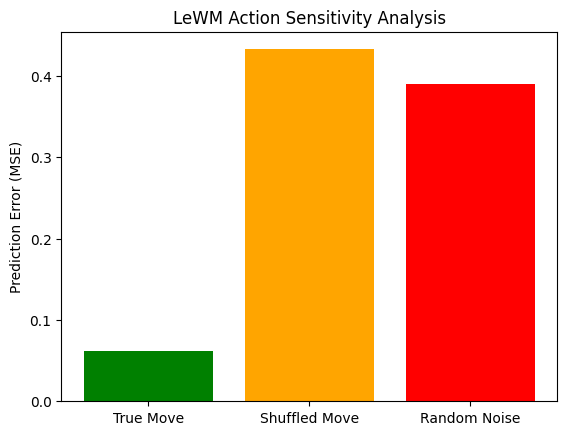

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("exports/chess_full.npz")

# Calculate MSE across the dataset
mse_true = np.mean((data['z'][:, 1:] - data['pred_true']) ** 2)
mse_shuffle = np.mean((data['z'][:, 1:] - data['pred_shuffle']) ** 2)
mse_random = np.mean((data['z'][:, 1:] - data['pred_random']) ** 2)

print(f"True Action MSE:    {mse_true:.4f}")
print(f"Shuffled Action MSE:{mse_shuffle:.4f}")
print(f"Random Action MSE:  {mse_random:.4f}")

# Plotting a bar chart to visualize the delta
plt.bar(['True Move', 'Shuffled Move', 'Random Noise'], [mse_true, mse_shuffle, mse_random], color=['green', 'orange', 'red'])
plt.ylabel('Prediction Error (MSE)')
plt.title('LeWM Action Sensitivity Analysis')
plt.show()

Loading latent arrays from 'exports/chess_full.npz'...
Calculating error metrics...

--- Latent Prediction Error (MSE) ---
1. No-Change Baseline: 0.26846 (Assuming pieces never move)
2. True Action:        0.06222 (Real move played)
3. Shuffled Action:    0.43269 (Wrong legal move)
4. Random Noise:       0.39037 (Complete garbage)

🧠 Causal Planning Gap: +0.37047
✅ PASS: Your model relies heavily on actions to predict the future.


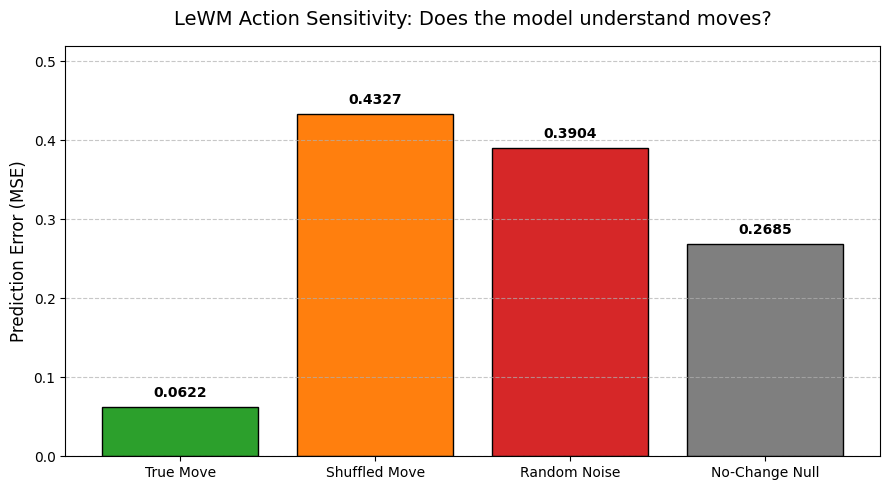

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load the Exported Data
# ------------------------------------------------------------
print("Loading latent arrays from 'exports/chess_full.npz'...")
try:
    data = np.load("exports/chess_full.npz")
except FileNotFoundError:
    raise FileNotFoundError("Could not find 'chess_full.npz'. Did the previous cell finish exporting?")

# Target is the next time step: z[t+1]
target = data['z'][:, 1:]
# The baseline is assuming the board doesn't change at all: z[t]
null_baseline = data['z'][:, :-1]

# ------------------------------------------------------------
# 2. Calculate Mean Squared Errors
# ------------------------------------------------------------
def calc_mse(pred, tgt):
    # Mean squared error across all dimensions and batches
    return np.mean((pred - tgt) ** 2)

print("Calculating error metrics...")
mse_null = calc_mse(null_baseline, target)
mse_true = calc_mse(data['pred_true'], target)
mse_shuffle = calc_mse(data['pred_shuffle'], target)
mse_random = calc_mse(data['pred_random'], target)

# ------------------------------------------------------------
# 3. Print the Results
# ------------------------------------------------------------
print("\n--- Latent Prediction Error (MSE) ---")
print(f"1. No-Change Baseline: {mse_null:.5f} (Assuming pieces never move)")
print(f"2. True Action:        {mse_true:.5f} (Real move played)")
print(f"3. Shuffled Action:    {mse_shuffle:.5f} (Wrong legal move)")
print(f"4. Random Noise:       {mse_random:.5f} (Complete garbage)")

causal_gap = mse_shuffle - mse_true
print(f"\n🧠 Causal Planning Gap: +{causal_gap:.5f}")
if causal_gap > 0:
    print("✅ PASS: Your model relies heavily on actions to predict the future.")
else:
    print("❌ FAIL: Your model is ignoring the action conditioning.")

# ------------------------------------------------------------
# 4. Plot the Ablation Chart
# ------------------------------------------------------------
labels = ['True Move', 'Shuffled Move', 'Random Noise', 'No-Change Null']
values = [mse_true, mse_shuffle, mse_random, mse_null]
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#7f7f7f']

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=1)

# Add the text values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(values)*0.02), 
             f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.title('LeWM Action Sensitivity: Does the model understand moves?', fontsize=14, pad=15)
plt.ylabel('Prediction Error (MSE)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(values) * 1.2) # Give headroom for text

plt.tight_layout()
plt.show()

✅ Model loaded on cuda from epoch 10
Imagination Drift over steps:
  Step 0: MSE 0.000000
  Step 1: MSE 0.234168
  Step 2: MSE 0.355255
  Step 3: MSE 0.598294
  Step 4: MSE 0.615115
  Step 5: MSE 0.619842


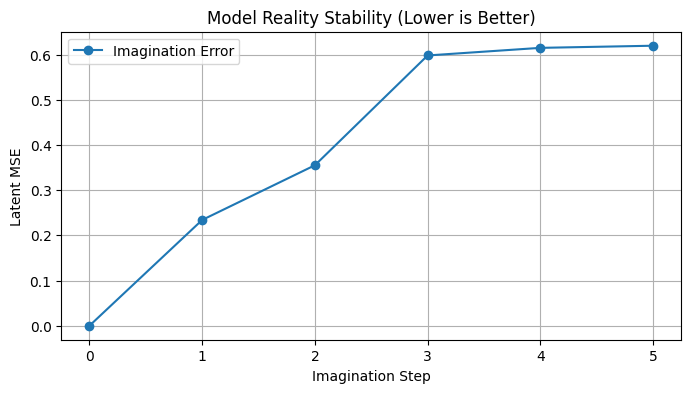

In [9]:
import sys
import os
import importlib.util
import torch
import numpy as np
import matplotlib.pyplot as plt
import chess
import random

# ------------------------------------------------------------
# 1. Import your script and load model
# ------------------------------------------------------------
script_name = "train.py"
if not os.path.exists(script_name):
    raise FileNotFoundError(f"Could not find '{script_name}'")

spec = importlib.util.spec_from_file_location("train_script", script_name)
train_script = importlib.util.module_from_spec(spec)
sys.modules["train_script"] = train_script
spec.loader.exec_module(train_script)

Config = train_script.Config
ChessLeWM = train_script.ChessLeWM
DEVICE = train_script.DEVICE

# Load checkpoint
cfg = Config()
latest_ckpt_path = os.path.join(cfg.out_dir, "lewm_chess_latest.pt")
if not os.path.exists(latest_ckpt_path):
    raise FileNotFoundError(f"No checkpoint at {latest_ckpt_path}")

checkpoint = torch.load(latest_ckpt_path, map_location=DEVICE, weights_only=False)
for k, v in checkpoint["cfg"].items():
    if hasattr(cfg, k):
        setattr(cfg, k, v)

model = ChessLeWM(cfg).to(DEVICE).eval()
model.load_state_dict(checkpoint["model"])
print(f"✅ Model loaded on {DEVICE} from epoch {checkpoint['epoch']}")

# ------------------------------------------------------------
# 2. Define the imagination test function (safe version)
# ------------------------------------------------------------
def run_imagination_test(model, cfg, board, steps=3):
    model.eval()
    with torch.no_grad():
        # Initial latent state
        z_t = model.encode_board(board).unsqueeze(0)  # (1, D)
        
        real_z_sequence = [z_t.cpu().numpy()]
        imagined_z_sequence = [z_t.cpu().numpy()]
        
        curr_z = z_t
        temp_board = board.copy()
        for i in range(steps):
            # Get legal moves; if none, break
            legal = list(temp_board.legal_moves)
            if not legal:
                break
            
            # Try to use the model's top move, but fallback to random if index out of range
            move = None
            vocab_size = model.policy_head[-1].out_features
            for m in legal:
                idx = train_script.move_to_idx(m)
                if 0 <= idx < vocab_size:
                    move = m
                    break
            if move is None:
                move = random.choice(legal)   # fallback to random
            
            move_idx = torch.tensor([train_script.move_to_idx(move)], device=DEVICE)
            move_emb = model.action_enc(move_idx.unsqueeze(0),
                                        torch.tensor([[0.0]], device=DEVICE))
            
            # Predict next latent state
            curr_z = model.predict(curr_z, move_emb)
            imagined_z_sequence.append(curr_z.cpu().numpy())
            
            # Apply move to the real board to get ground truth next latent
            temp_board.push(move)
            real_z_sequence.append(model.encode_board(temp_board).unsqueeze(0).cpu().numpy())
    
    # Convert lists to numpy arrays
    real_arr = np.array(real_z_sequence)      # (T, 1, D) or (T, D) depending on shape
    imag_arr = np.array(imagined_z_sequence)
    
    # Squeeze to remove singleton dimension if present
    if real_arr.ndim == 3 and real_arr.shape[1] == 1:
        real_arr = real_arr[:, 0, :]
        imag_arr = imag_arr[:, 0, :]
    
    return real_arr, imag_arr

# ------------------------------------------------------------
# 3. Run the test on the starting position
# ------------------------------------------------------------
test_board = chess.Board()
real_z, imag_z = run_imagination_test(model, cfg, test_board, steps=5)

# Calculate drift per step (MSE between imagined and real)
drift = []
for i in range(len(real_z)):
    mse = float(np.mean((real_z[i] - imag_z[i]) ** 2))
    drift.append(mse)

steps_range = list(range(len(drift)))

print("Imagination Drift over steps:")
for i, d in enumerate(drift):
    print(f"  Step {i}: MSE {d:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(steps_range, drift, marker='o', label='Imagination Error')
plt.title("Model Reality Stability (Lower is Better)")
plt.xlabel("Imagination Step")
plt.ylabel("Latent MSE")
plt.grid(True)
plt.legend()
plt.show()

--- Embedding Health Report ---
Total Latent Dimensions: 256
Dead Dimensions (Std < 0.001): 0
Effective Rank (Dimensionality Usage): 30


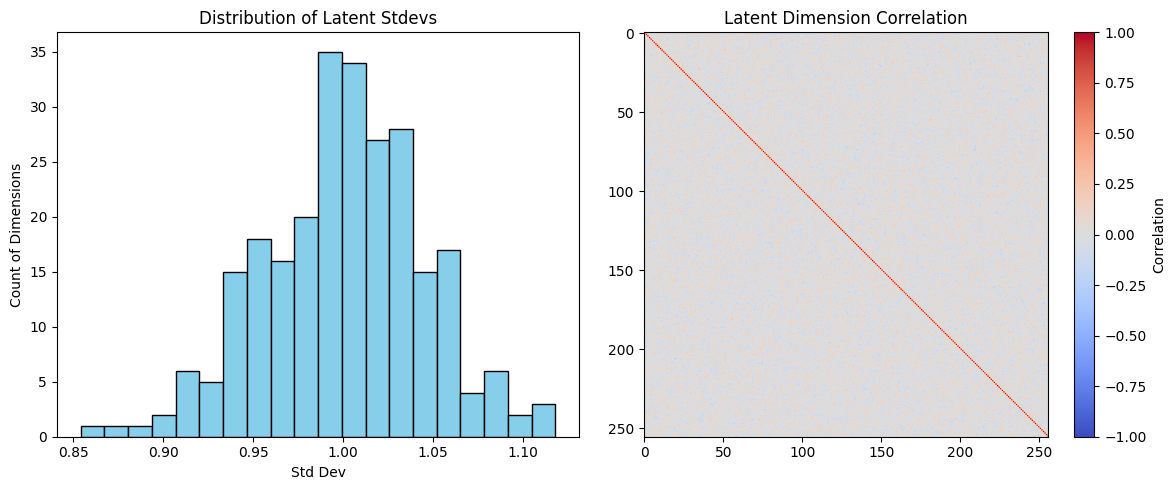

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the latent representations
data = np.load("exports/chess_full.npz")
z = data['z'] # Shape [N, T, D]
# Flatten to [N*T, D] to look at the global distribution
z_flat = z.reshape(-1, z.shape[-1])

# 2. Metrics for Embedding Health
# A. Standard Deviation per dimension (Detecting "dead" neurons)
std_per_dim = np.std(z_flat, axis=0)
num_dead = np.sum(std_per_dim < 1e-3)

# B. Effective Rank (Are we using all dimensions?)
# Compute singular values
_, S, _ = np.linalg.svd(z_flat - np.mean(z_flat, axis=0), full_matrices=False)
var_explained = (S**2) / np.sum(S**2)
effective_rank = np.sum(var_explained > 0.01) # How many dims carry 99% of info?

# C. Correlation Matrix (Checking for redundancy)
corr_matrix = np.corrcoef(z_flat, rowvar=False)

print(f"--- Embedding Health Report ---")
print(f"Total Latent Dimensions: {z.shape[-1]}")
print(f"Dead Dimensions (Std < 0.001): {num_dead}")
print(f"Effective Rank (Dimensionality Usage): {effective_rank}")

# 3. Visualization
plt.figure(figsize=(12, 5))

# Plot 1: Variance distribution
plt.subplot(1, 2, 1)
plt.hist(std_per_dim, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Latent Stdevs")
plt.xlabel("Std Dev")
plt.ylabel("Count of Dimensions")

# Plot 2: Correlation Heatmap
plt.subplot(1, 2, 2)
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title("Latent Dimension Correlation")
plt.tight_layout()
plt.show()